# v2a-RSN c-GC* connectivity for 220119_F2_run11 (FastGcStar)

This notebook processes exactly one v2a-RSN recording. The four recordings are split into separate notebooks so a long run can be stopped, restarted, or parallelized per fish.

The long-running cell saves `outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11.pkl` after each completed `p_value`. On rerun, existing p-values are detected and skipped when `SKIP_EXISTING=True`.


In [1]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

CAUSALISED_GC_RELATIVE_PATH = Path('src/markovianity_diagnostic/core/causalised-GC.py')
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (path / CAUSALISED_GC_RELATIVE_PATH).exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find '{CAUSALISED_GC_RELATIVE_PATH}' from {Path.cwd().resolve()}"
    )

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from markovianity_diagnostic.core import FastGcStar as GcStar
from markovianity_diagnostic.experiments.graph_metrics import compute_graph_stability_metrics
from markovianity_diagnostic.experiments.v2a_rsn_utils import (
    binarize_adjacencies,
    build_v2a_stability_summary,
    build_v2a_transition_df,
    completed_p_values,
    load_adjacency_checkpoint,
    load_and_filter_traces,
    save_adjacency_checkpoint,
    setup_recording_paths,
    upsert_method_outputs,
    upsert_summary_json,
    v2a_summary_json_payload,
)

print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics


## Configuration

The GcStar parameters are explicit below. To recompute an already-saved p-value, set `SKIP_EXISTING=False` and `REPLACE_EXISTING_P=True`.

`N_LAGS` is set to 1 so changes across `P_VALUES = [1, 2, 3, 4, 5, 6, 7]` reflect variation with respect to the conditioning set rather than aggregation across multiple lag blocks.


In [2]:
RECORDING_NAME = '220119_F2_run11'
METHOD_DIR = 'c-GC-star-fast'
METHOD_LABEL = 'c-GC*'
GCSTAR_METHOD = 'fcgc'

P_VALUES = [1, 2, 3, 4, 5, 6, 7]
N_LAGS = 1
N_PERM = 1000
ALPHA = 0.01
BETA = 0.001
TEMPORAL = True
SIMULATION = False
VERBOSE = 0

SKIP_EXISTING = True
REPLACE_EXISTING_P = False
RUN_STABILITY_EXPORTS_WHEN_PARTIAL = False

GCSTAR_PARAMS = {
    'method': GCSTAR_METHOD,
    'n_perm': N_PERM,
    'n_lags': N_LAGS,
    'alpha': ALPHA,
    'beta': BETA,
    'temporal': TEMPORAL,
    'simulation': SIMULATION,
    'verbose': VERBOSE,
}

print(f'Recording: {RECORDING_NAME}')
print(f'Method: {METHOD_LABEL} (GcStar method={GCSTAR_METHOD})')
print('GcStar parameters:')
display(pd.Series(GCSTAR_PARAMS, name='value').to_frame())
print(f'Skip existing p_values: {SKIP_EXISTING}')
print(f'Replace existing p_values: {REPLACE_EXISTING_P}')


Recording: 220119_F2_run11
Method: c-GC* (GcStar method=fcgc)
GcStar parameters:


,value
method,fcgc
n_perm,1000
n_lags,1
alpha,0.01
beta,0.001
temporal,True
simulation,False
verbose,0


Skip existing p_values: True
Replace existing p_values: False


In [3]:
paths = setup_recording_paths(PROJECT_ROOT, RECORDING_NAME, METHOD_DIR)
recording_dir = paths['recording_dir']
recording_output_dir = paths['output_dir']
method_output_dir = PROJECT_ROOT / 'outputs' / 'v2a-RSNs' / METHOD_DIR
connectivity_pkl = method_output_dir / f'{RECORDING_NAME}.pkl'
metadata_path = recording_output_dir / 'run_metadata.json'

method_output_dir.mkdir(parents=True, exist_ok=True)
recording_output_dir.mkdir(parents=True, exist_ok=True)

print(f'Data directory: {recording_dir.relative_to(PROJECT_ROOT)}')
print(f'Checkpoint pickle: {connectivity_pkl.relative_to(PROJECT_ROOT)}')
print(f'Recording metadata directory: {recording_output_dir.relative_to(PROJECT_ROOT)}')


Data directory: data/v2a-RSNs/220119_F2_run11
Checkpoint pickle: outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11.pkl
Recording metadata directory: outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11


## Run or Resume p-values

You can interrupt the notebook after any `Saved P=...` message. The next run reloads the checkpoint and skips completed p-values.


In [4]:
X = load_and_filter_traces(recording_dir, RECORDING_NAME)
print(f'Filtered traces shape (neurons x frames): {X.shape}')

adjacencies = load_adjacency_checkpoint(connectivity_pkl)
completed_before = completed_p_values(adjacencies, P_VALUES)
print(f'Already completed p_values: {completed_before if completed_before else "none"}')

for p_value in tqdm(P_VALUES, desc=f'{METHOD_LABEL} p_values', unit='p'):
    if p_value in adjacencies and SKIP_EXISTING:
        tqdm.write(f'Skipping P={p_value}: already present in {connectivity_pkl.name}')
        continue
    if p_value in adjacencies and not REPLACE_EXISTING_P:
        raise ValueError(
            f'P={p_value} already exists in {connectivity_pkl}. '
            'Set SKIP_EXISTING=True or REPLACE_EXISTING_P=True.'
        )

    estimator = GcStar(
        n_perm=N_PERM,
        n_pasts=p_value,
        n_lags=N_LAGS,
        temporal=TEMPORAL,
        method=GCSTAR_METHOD,
    )
    estimator.fit(X, verbose=VERBOSE)
    connectivity = estimator.get_connectivity_matrix(
        alpha=ALPHA,
        beta=BETA,
        simulation=SIMULATION,
    )

    adjacency = (np.asarray(connectivity) != 0).astype(int)
    np.fill_diagonal(adjacency, 0)
    adjacencies[p_value] = adjacency
    save_adjacency_checkpoint(connectivity_pkl, adjacencies)

    run_metadata = {
        'saved_at': datetime.now(timezone.utc).isoformat(),
        'recording': RECORDING_NAME,
        'method_label': METHOD_LABEL,
        'gcstar_method': GCSTAR_METHOD,
        'trace_shape_neurons_by_frames': list(X.shape),
        'p_values_requested': P_VALUES,
        'p_values_completed': completed_p_values(adjacencies, P_VALUES),
        'last_completed_p_value': int(p_value),
        'gcstar_params': GCSTAR_PARAMS,
        'connectivity_pickle': str(connectivity_pkl.relative_to(PROJECT_ROOT)),
    }
    metadata_path.write_text(json.dumps(run_metadata, indent=2), encoding='utf-8')
    tqdm.write(f'Saved P={p_value} to {connectivity_pkl.relative_to(PROJECT_ROOT)}')

completed_after = completed_p_values(adjacencies, P_VALUES)
missing_p_values = [p_value for p_value in P_VALUES if p_value not in adjacencies]
analysis_complete = not missing_p_values

print(f'Completed p_values: {completed_after}')
if missing_p_values:
    print(f'Missing p_values: {missing_p_values}')
    print('Partial checkpoint is saved. Rerun this cell later to continue from the missing p_values.')
else:
    print('All requested p_values are complete.')


Filtered traces shape (neurons x frames): (100, 3601)
Already completed p_values: none


c-GC* p_values:  14%|█▍        | 1/7 [00:13<01:18, 13.01s/p]

Saved P=1 to outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11.pkl


c-GC* p_values:  29%|██▊       | 2/7 [00:31<01:20, 16.11s/p]

Saved P=2 to outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11.pkl


...

Saved P=5 to outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11.pkl


c-GC* p_values:  86%|████████▌ | 6/7 [03:01<00:39, 39.37s/p]

Saved P=6 to outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11.pkl


c-GC* p_values: 100%|██████████| 7/7 [03:51<00:00, 33.11s/p]


Saved P=7 to outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11.pkl
Completed p_values: [1, 2, 3, 4, 5, 6, 7]
All requested p_values are complete.


## Stability Metrics and Aggregate Outputs

Metrics are exported only when all requested p-values are present, unless `RUN_STABILITY_EXPORTS_WHEN_PARTIAL=True`.


In [5]:
if missing_p_values and not RUN_STABILITY_EXPORTS_WHEN_PARTIAL:
    print('Skipping stability exports because the checkpoint is partial.')
    print('Set RUN_STABILITY_EXPORTS_WHEN_PARTIAL=True if you intentionally want partial metrics.')
    summary_df = pd.DataFrame()
    transition_df = pd.DataFrame()
else:
    adjacencies_binary = binarize_adjacencies(adjacencies)
    metrics = compute_graph_stability_metrics(adjacencies_binary)

    summary = build_v2a_stability_summary(
        RECORDING_NAME,
        connectivity_pkl,
        adjacencies_binary,
        metrics,
    )
    transition_df = build_v2a_transition_df(
        RECORDING_NAME,
        connectivity_pkl.name,
        adjacencies_binary,
        metrics,
    )
    summary_df = pd.DataFrame([summary])

    for column in [
        'previous_P',
        'previous_edge_count',
        'edge_delta',
        'net_edge_loss_count',
        'edge_deletions',
        'edge_additions',
        'net_deletion_count',
    ]:
        transition_df[column] = transition_df[column].astype('Int64')

    upsert_method_outputs(summary_df, transition_df, method_output_dir)
    upsert_summary_json(v2a_summary_json_payload(summary), method_output_dir / 'summary.json')

    summary_df.to_csv(recording_output_dir / 'summary.csv', index=False)
    transition_df.to_csv(recording_output_dir / 'transitions.csv', index=False)
    (recording_output_dir / 'summary.json').write_text(
        json.dumps(v2a_summary_json_payload(summary), indent=2),
        encoding='utf-8',
    )

    print(f'Updated method-level outputs in {method_output_dir.relative_to(PROJECT_ROOT)}')
    print(f'Updated recording-level outputs in {recording_output_dir.relative_to(PROJECT_ROOT)}')


Updated method-level outputs in outputs/v2a-RSNs/c-GC-star-fast
Updated recording-level outputs in outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11


In [6]:
if summary_df.empty:
    print('No summary table available yet because the checkpoint is partial.')
else:
    summary_columns = [
        'dataset',
        'file',
        'n_nodes',
        'n_possible_edges',
        'n_p_values',
        'T_obs',
        'T_obs_depth',
        'T_minus_obs',
        'T_plus_obs',
        'first_step_drop_count',
        'first_step_drop_fraction',
        'drop_to_min_count',
        'drop_to_min_fraction',
        'final_drop_count',
        'final_drop_fraction',
        'cumulative_D_p',
        'cumulative_D_minus',
        'cumulative_D_plus',
        'mean_post_first_D_p',
        'max_post_first_D_p',
    ]
    display(summary_df[summary_columns])


,dataset,file,n_nodes,n_possible_edges,n_p_values,T_obs,T_obs_depth,T_minus_obs,T_plus_obs,first_step_drop_count,first_step_drop_fraction,drop_to_min_count,drop_to_min_fraction,final_drop_count,final_drop_fraction,cumulative_D_p,cumulative_D_minus,cumulative_D_plus,mean_post_first_D_p,max_post_first_D_p
0,220119_F2_run11,220119_F2_run11.pkl,100,9900,7,0.014646,2,0.011414,0.004545,81,0.223757,108,0.298343,76,0.209945,0.051515,0.029596,0.021919,0.007374,0.008788


In [7]:
if transition_df.empty:
    print('No transition table available yet because the checkpoint is partial.')
else:
    transition_columns = [
        'dataset',
        'P',
        'edge_count',
        'previous_edge_count',
        'edge_delta',
        'edge_deletions',
        'edge_additions',
        'net_deletion_count',
        'D_p',
        'D_minus',
        'D_plus',
        'deletion_share_of_changes',
        'addition_share_of_changes',
        'net_deletion_fraction_possible',
    ]
    display(transition_df[transition_columns])


,dataset,P,edge_count,previous_edge_count,edge_delta,edge_deletions,edge_additions,net_deletion_count,D_p,D_minus,D_plus,deletion_share_of_changes,addition_share_of_changes,net_deletion_fraction_possible
0,220119_F2_run11,1,362,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
1,220119_F2_run11,2,281,362,-81,113,32,81,0.014646,0.011414,0.003232,0.779310,0.220690,0.008182
2,220119_F2_run11,3,266,281,-15,51,36,15,0.008788,0.005152,0.003636,0.586207,0.413793,0.001515
3,220119_F2_run11,4,254,266,-12,32,20,12,0.005253,0.003232,0.002020,0.615385,0.384615,0.001212
4,220119_F2_run11,5,273,254,19,26,45,-19,0.007172,0.002626,0.004545,0.366197,0.633803,-0.001919
5,220119_F2_run11,6,281,273,8,36,44,-8,0.008081,0.003636,0.004444,0.450000,0.550000,-0.000808
6,220119_F2_run11,7,286,281,5,35,40,-5,0.007576,0.003535,0.004040,0.466667,0.533333,-0.000505


## Diagnostic Plots

Plots are written to the recording-level output directory.


Saved plot to: outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11/npasts_links.png


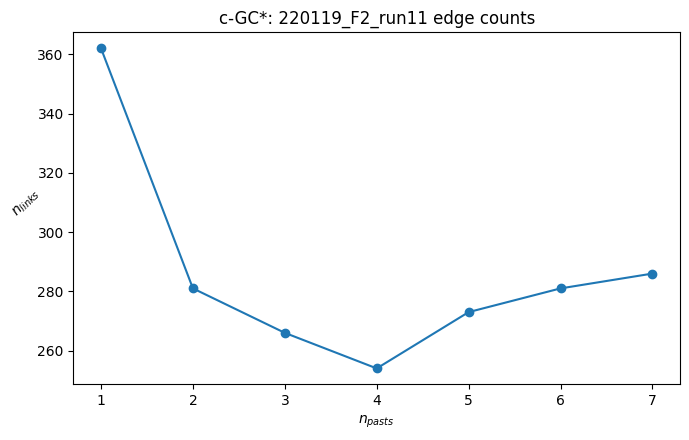

In [8]:
if transition_df.empty:
    print('Skipping plot because no transition table is available yet.')
else:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(transition_df['P'], transition_df['edge_count'], marker='o', color='tab:blue')
    ax.set_xlabel('$n_{pasts}$')
    ax.set_ylabel('$n_{links}$', rotation=45)
    ax.set_title(f'{METHOD_LABEL}: {RECORDING_NAME} edge counts')
    ax.set_xticks(transition_df['P'].tolist())
    ax.grid(False)
    plt.tight_layout()

    out_path = recording_output_dir / 'npasts_links.png'
    fig.savefig(out_path, dpi=200)
    print(f'Saved plot to: {out_path.relative_to(PROJECT_ROOT)}')
    plt.show()


Saved plot to: outputs/v2a-RSNs/c-GC-star-fast/220119_F2_run11/instability_decomposition.png


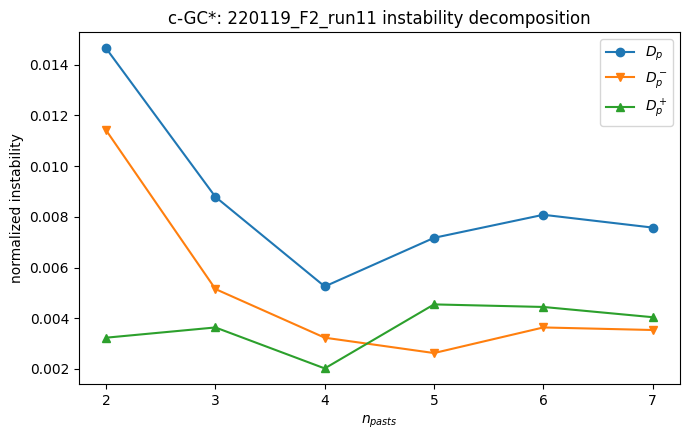

In [9]:
if transition_df.empty or transition_df['D_p'].notna().sum() == 0:
    print('Skipping plot because no transition instability values are available yet.')
else:
    subset = transition_df[transition_df['D_p'].notna()]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(subset['P'], subset['D_p'], marker='o', label='$D_p$')
    ax.plot(subset['P'], subset['D_minus'], marker='v', label='$D_p^-$')
    ax.plot(subset['P'], subset['D_plus'], marker='^', label='$D_p^+$')
    ax.set_title(f'{METHOD_LABEL}: {RECORDING_NAME} instability decomposition')
    ax.set_xlabel('$n_{pasts}$')
    ax.set_ylabel('normalized instability')
    ax.legend()
    ax.grid(False)
    plt.tight_layout()

    out_path = recording_output_dir / 'instability_decomposition.png'
    fig.savefig(out_path, dpi=200)
    print(f'Saved plot to: {out_path.relative_to(PROJECT_ROOT)}')
    plt.show()
